# Analisi delle Ispezioni Alimentari di Chicago

Questo notebook analizza il dataset delle ispezioni alimentari della città di Chicago, disponibile su [Kaggle](https://www.kaggle.com/datasets/chicago/chicago-food-inspections) e sul [Chicago Data Portal](https://data.cityofchicago.org/).

Vengono risposta a 20 domande analitiche sulla sicurezza alimentare.

## 0. Setup e Caricamento Dati

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from collections import Counter
import re

warnings.filterwarnings('ignore')

# Stile grafico uniforme
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

print('Librerie caricate.')

Librerie caricate.


In [5]:
df_raw = pd.read_csv('food-inspections.csv', low_memory=False)
print(f'Dataset scaricato: {df_raw.shape[0]:,} righe × {df_raw.shape[1]} colonne')

Dataset scaricato: 196,825 righe × 22 colonne


In [6]:
df_raw.head(3)

,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,...,Results,Violations,Latitude,Longitude,Location,Historical Wards 2003-2015,Zip Codes,Community Areas,Census Tracts,Wards
0,2352683,CHIPOTLE MEXICAN GRILL,CHIPOTLE MEXICAN GRILL,2670642.0,Restaurant,Risk 1 (High),1025 W ADDISON ST,CHICAGO,IL,60613.0,...,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.947118,-87.655381,"{'latitude': '-87.6553811622124', 'longitude':...",NaN,NaN,NaN,NaN,NaN
1,2352734,CHILI'S T-I,CHILI'S (T1-B14),34169.0,Restaurant,Risk 1 (High),11601 W TOUHY AVE,CHICAGO,IL,60666.0,...,Pass,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,42.008536,-87.914428,"{'latitude': '-87.91442843927047', 'longitude'...",NaN,NaN,NaN,NaN,NaN
2,2352713,NICK'S FIRE GRILL STEAK & LEMONADE INC.,NICK'S FIRE GRILL STEAK & LEMONADE INC.,2699090.0,NaN,Risk 1 (High),2900 W 63RD ST,CHICAGO,IL,60629.0,...,Not Ready,NaN,41.779190,-87.695892,"{'latitude': '-87.69589237398256', 'longitude'...",NaN,NaN,NaN,NaN,NaN


In [7]:
# ── Pulizia colonne ──────────────────────────────────────────────
df = df_raw.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '_', regex=True)
)

# Date
df['inspection_date'] = pd.to_datetime(df['inspection_date'], errors='coerce')
df['year']   = df['inspection_date'].dt.year
df['month']  = df['inspection_date'].dt.month
df['quarter']= df['inspection_date'].dt.quarter

# Esito binario
df['results_clean'] = df['results'].str.strip().str.title()
df['failed'] = df['results_clean'].isin(['Fail']).astype(int)
df['passed'] = df['results_clean'].isin(['Pass', 'Pass W/ Conditions']).astype(int)

# Rischio
df['risk_clean'] = df['risk'].str.strip().str.title().str.replace(r'Risk\s+', '', regex=True)

# ZIP code
df['zip'] = df['zip'].astype(str).str.extract(r'(\d{5})')[0]

# Conteggio violazioni
def count_violations(v):
    if pd.isna(v) or v == '':
        return 0
    return len(re.findall(r'\|', str(v))) + 1

df['n_violations'] = df['violations'].apply(count_violations)

print('Pulizia completata.')
print(df[['inspection_date','facility_type','risk_clean','results_clean','failed','n_violations']].head())

Pulizia completata.
  inspection_date                 facility_type risk_clean  \
0      2019-12-04                    Restaurant   1 (High)   
1      2019-12-04                    Restaurant   1 (High)   
2      2019-12-04                           NaN   1 (High)   
3      2019-12-04                    Restaurant   1 (High)   
4      2019-12-04  Children's Services Facility   1 (High)   

        results_clean  failed  n_violations  
0  Pass W/ Conditions       0             1  
1                Pass       0             5  
2           Not Ready       0             0  
3  Pass W/ Conditions       0             6  
4                Pass       0             0  


---
## 1. Quali tipi di esercizi alimentari vengono ispezionati più spesso?

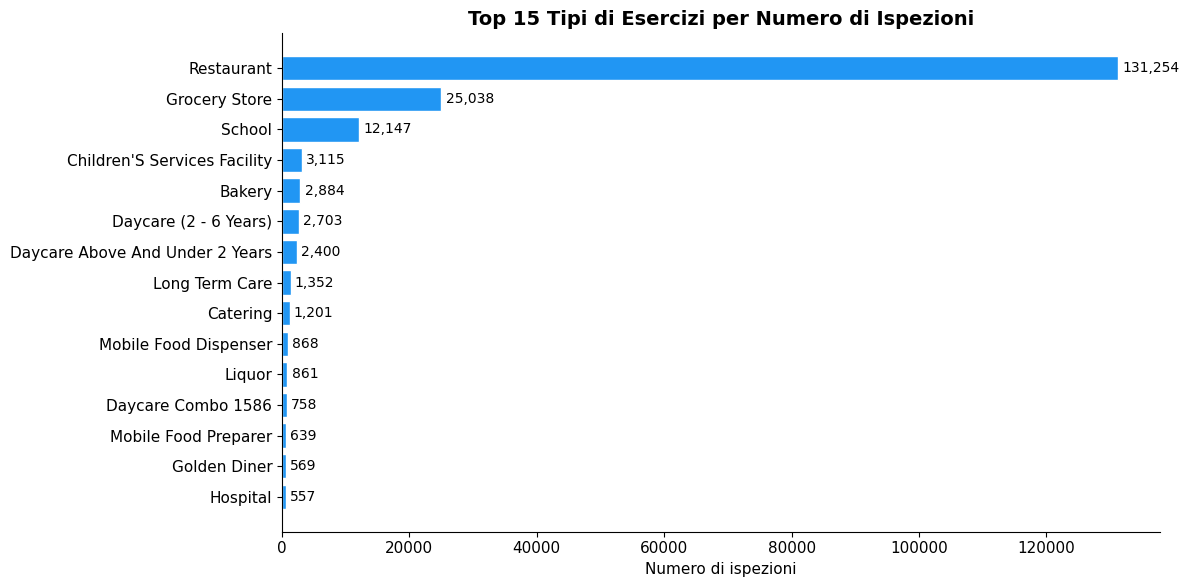

facility_type
Restaurant                         131254
Grocery Store                       25038
School                              12147
Children'S Services Facility         3115
Bakery                               2884
Daycare (2 - 6 Years)                2703
Daycare Above And Under 2 Years      2400
Long Term Care                       1352
Catering                             1201
Mobile Food Dispenser                 868
Liquor                                861
Daycare Combo 1586                    758
Mobile Food Preparer                  639
Golden Diner                          569
Hospital                              557


In [9]:
top_facilities = (
    df['facility_type']
    .str.strip().str.title()
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_facilities.index[::-1], top_facilities.values[::-1],
               color=PALETTE[0], edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=10)
ax.set_xlabel('Numero di ispezioni')
ax.set_title('Top 15 Tipi di Esercizi per Numero di Ispezioni', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(top_facilities.to_string())

---
## 2. Le attività ad alto rischio falliscono più spesso rispetto a quelle a basso rischio?

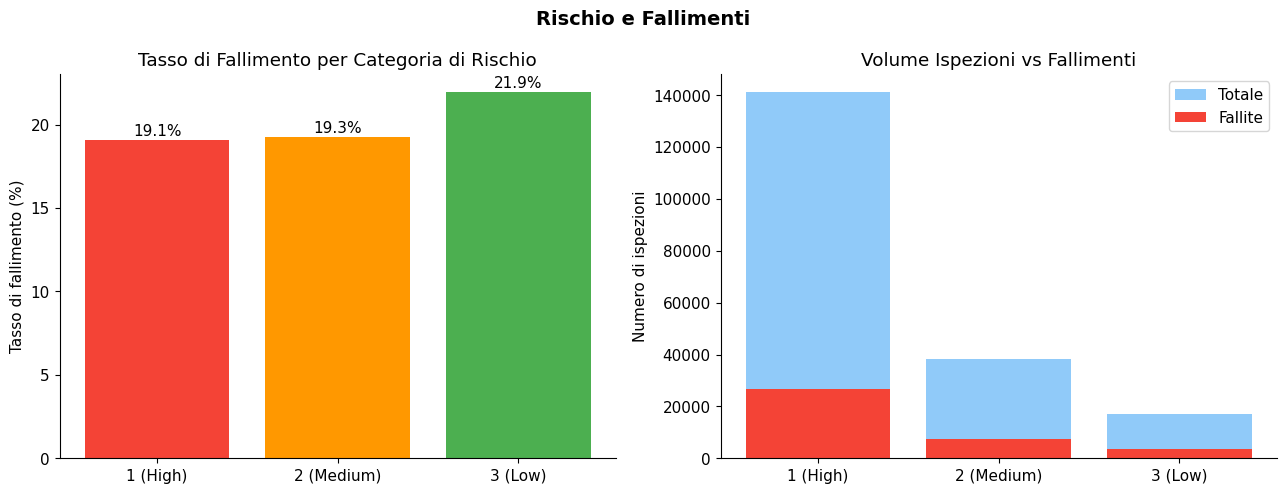

risk_clean  n_total  n_fail  fail_pct
  1 (High)   141129   26896 19.057741
2 (Medium)    38431    7398 19.250085
   3 (Low)    17165    3766 21.939994


In [10]:
risk_order = ['1 (High)', '2 (Medium)', '3 (Low)', 'All']

fail_by_risk = (
    df[df['risk_clean'].isin(['1 (High)', '2 (Medium)', '3 (Low)'])]
    .groupby('risk_clean')['failed']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean':'fail_rate', 'sum':'n_fail', 'count':'n_total'})
    .reindex([r for r in risk_order if r != 'All'])
    .reset_index()
)
fail_by_risk['fail_pct'] = fail_by_risk['fail_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [PALETTE[1], PALETTE[3], PALETTE[2]]

axes[0].bar(fail_by_risk['risk_clean'], fail_by_risk['fail_pct'], color=colors)
axes[0].set_ylabel('Tasso di fallimento (%)')
axes[0].set_title('Tasso di Fallimento per Categoria di Rischio')
for i, (_, row) in enumerate(fail_by_risk.iterrows()):
    axes[0].text(i, row['fail_pct'] + 0.3, f"{row['fail_pct']:.1f}%", ha='center', fontsize=11)

axes[1].bar(fail_by_risk['risk_clean'], fail_by_risk['n_total'], color='#90CAF9', label='Totale')
axes[1].bar(fail_by_risk['risk_clean'], fail_by_risk['n_fail'], color=PALETTE[1], label='Fallite')
axes[1].set_ylabel('Numero di ispezioni')
axes[1].set_title('Volume Ispezioni vs Fallimenti')
axes[1].legend()

plt.suptitle('Rischio e Fallimenti', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(fail_by_risk[['risk_clean','n_total','n_fail','fail_pct']].to_string(index=False))

---
## 3. Come sono distribuiti gli esiti delle ispezioni tra le diverse categorie di rischio?

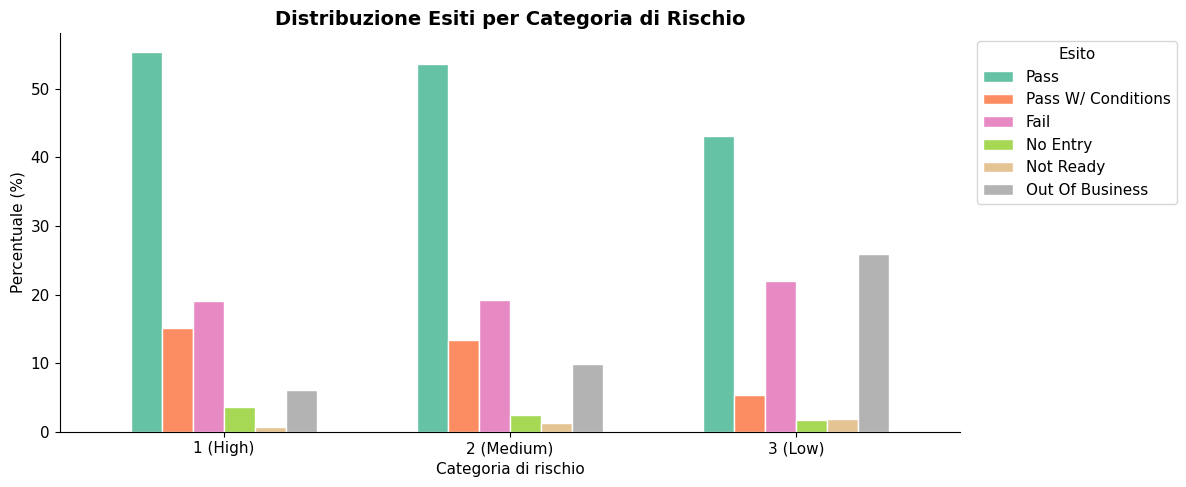

results_clean  Pass  Pass W/ Conditions  Fail  No Entry  Not Ready  Out Of Business
risk_clean                                                                         
1 (High)       55.3                15.1  19.1       3.6        0.7              6.1
2 (Medium)     53.6                13.4  19.3       2.5        1.3              9.9
3 (Low)        43.1                 5.3  21.9       1.7        1.9             25.9


In [11]:
df_risk = df[df['risk_clean'].isin(['1 (High)', '2 (Medium)', '3 (Low)'])].copy()

outcome_dist = (
    df_risk.groupby(['risk_clean', 'results_clean'])
    .size()
    .reset_index(name='count')
)
outcome_pct = outcome_dist.copy()
totals = outcome_pct.groupby('risk_clean')['count'].transform('sum')
outcome_pct['pct'] = outcome_pct['count'] / totals * 100

pivot = outcome_pct.pivot(index='risk_clean', columns='results_clean', values='pct').fillna(0)

main_outcomes = [c for c in ['Pass', 'Pass W/ Conditions', 'Fail', 'No Entry', 'Not Ready', 'Out Of Business'] if c in pivot.columns]
pivot = pivot[main_outcomes]

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.65)
ax.set_xlabel('Categoria di rischio')
ax.set_ylabel('Percentuale (%)')
ax.set_title('Distribuzione Esiti per Categoria di Rischio', fontsize=14, fontweight='bold')
ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title='Esito', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(pivot.round(1).to_string())

---
## 4. Il tasso di fallimento è cambiato nel tempo?

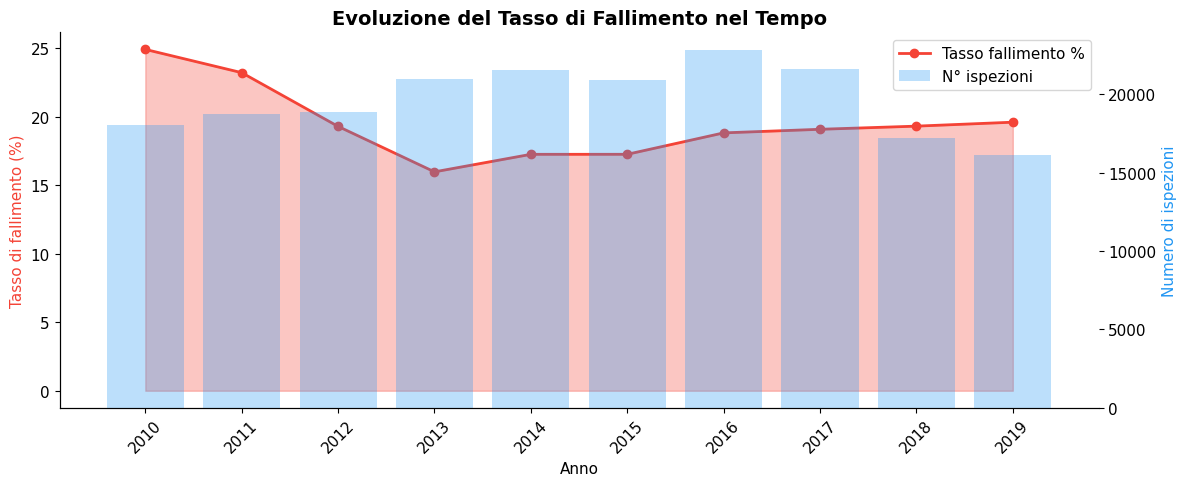

 year  n_inspections  fail_pct
 2010          18068 24.928050
 2011          18748 23.229144
 2012          18866 19.304569
 2013          20951 15.984917
 2014          21540 17.265552
 2015          20912 17.267598
 2016          22818 18.831624
 2017          21588 19.093941
 2018          17191 19.324065
 2019          16143 19.612216


In [12]:
df_yr = df[df['year'].between(2010, 2023)]

yearly = (
    df_yr.groupby('year')['failed']
    .agg(['mean', 'count'])
    .rename(columns={'mean':'fail_rate', 'count':'n_inspections'})
    .reset_index()
)
yearly['fail_pct'] = yearly['fail_rate'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.fill_between(yearly['year'], yearly['fail_pct'], alpha=0.3, color=PALETTE[1])
ax1.plot(yearly['year'], yearly['fail_pct'], marker='o', color=PALETTE[1], linewidth=2, label='Tasso fallimento %')
ax2.bar(yearly['year'], yearly['n_inspections'], alpha=0.3, color=PALETTE[0], label='N° ispezioni')

ax1.set_xlabel('Anno')
ax1.set_ylabel('Tasso di fallimento (%)', color=PALETTE[1])
ax2.set_ylabel('Numero di ispezioni', color=PALETTE[0])
ax1.set_title('Evoluzione del Tasso di Fallimento nel Tempo', fontsize=14, fontweight='bold')
ax1.set_xticks(yearly['year'])
ax1.set_xticklabels(yearly['year'].astype(int), rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(yearly[['year','n_inspections','fail_pct']].to_string(index=False))

---
## 5. Esistono pattern stagionali nelle ispezioni o nei fallimenti?

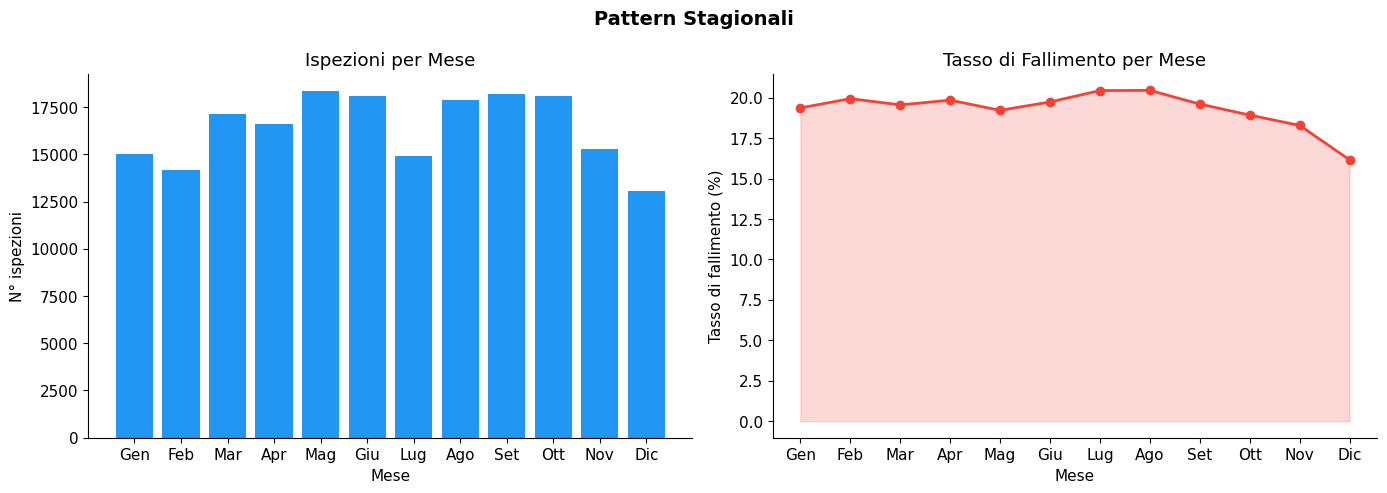

month_name  n_inspections  fail_pct
       Gen          15014 19.368589
       Feb          14191 19.942217
       Mar          17136 19.555322
       Apr          16605 19.849443
       Mag          18347 19.218401
       Giu          18073 19.736624
       Lug          14919 20.443729
       Ago          17855 20.453654
       Set          18218 19.606982
       Ott          18113 18.925634
       Nov          15273 18.287173
       Dic          13081 16.160844


In [13]:
month_names = ['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic']

monthly = (
    df.groupby('month')['failed']
    .agg(['mean', 'count'])
    .rename(columns={'mean':'fail_rate', 'count':'n_inspections'})
    .reset_index()
)
monthly['fail_pct'] = monthly['fail_rate'] * 100
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly['month_name'], monthly['n_inspections'], color=PALETTE[0])
axes[0].set_title('Ispezioni per Mese')
axes[0].set_xlabel('Mese')
axes[0].set_ylabel('N° ispezioni')

axes[1].plot(monthly['month_name'], monthly['fail_pct'], marker='o', color=PALETTE[1], linewidth=2)
axes[1].fill_between(range(len(monthly)), monthly['fail_pct'], alpha=0.2, color=PALETTE[1])
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['month_name'])
axes[1].set_title('Tasso di Fallimento per Mese')
axes[1].set_xlabel('Mese')
axes[1].set_ylabel('Tasso di fallimento (%)')

plt.suptitle('Pattern Stagionali', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(monthly[['month_name','n_inspections','fail_pct']].to_string(index=False))

---
## 6. In alcuni periodi le ispezioni hanno una probabilità maggiore di concludersi con un fallimento?

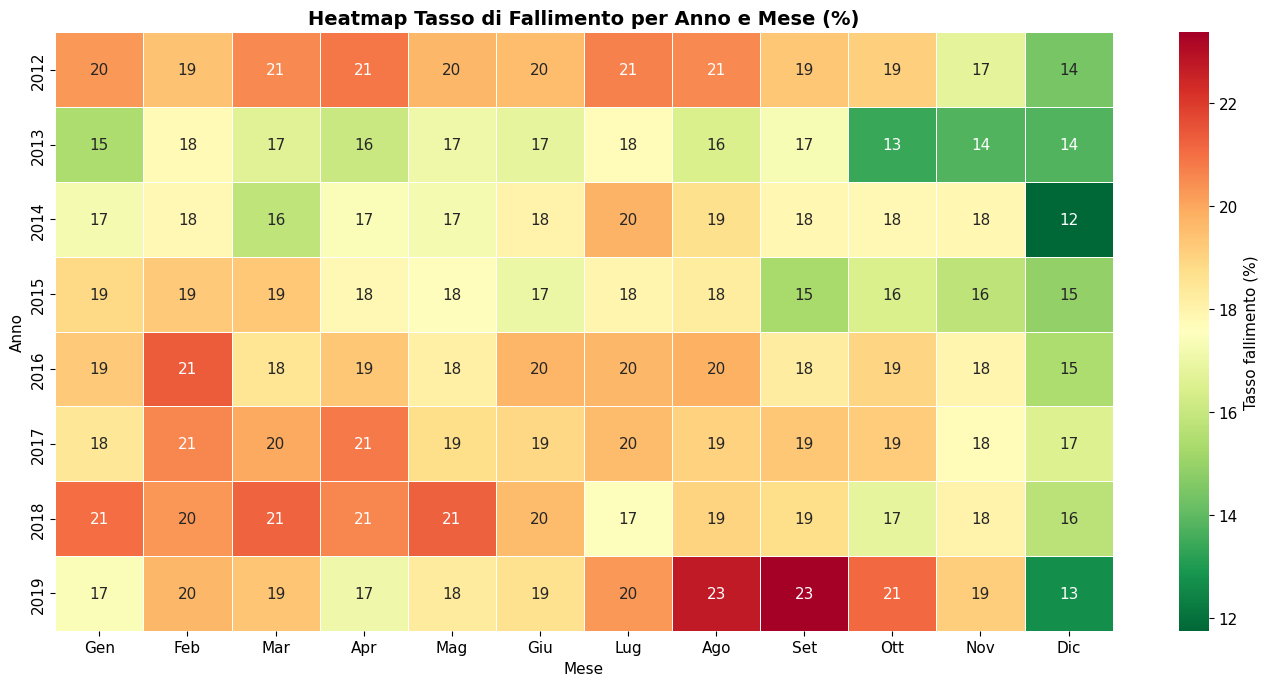

In [14]:
# Heatmap Anno x Mese del tasso di fallimento
df_hm = df[df['year'].between(2012, 2023)]

heatmap_data = (
    df_hm.groupby(['year', 'month'])['failed']
    .mean()
    .unstack('month') * 100
)
heatmap_data.columns = [month_names[m-1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Tasso fallimento (%)'}
)
ax.set_title('Heatmap Tasso di Fallimento per Anno e Mese (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mese')
ax.set_ylabel('Anno')
plt.tight_layout()
plt.show()

---
## 7. Quali CAP o aree registrano il numero più alto di ispezioni fallite?

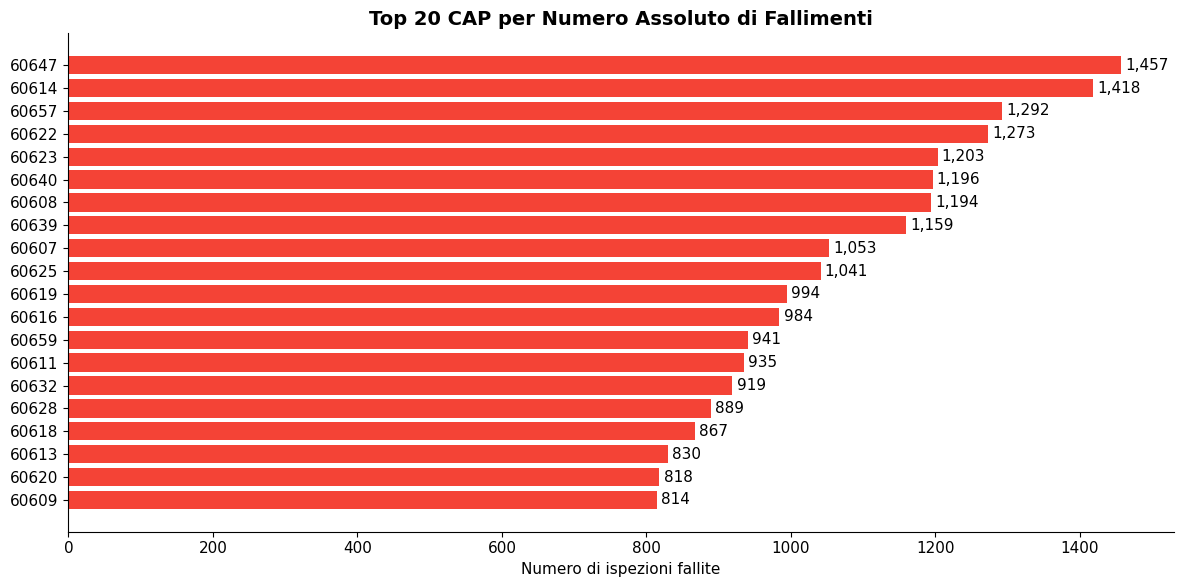

zip
60647    1457
60614    1418
60657    1292
60622    1273
60623    1203
60640    1196
60608    1194
60639    1159
60607    1053
60625    1041
60619     994
60616     984
60659     941
60611     935
60632     919
60628     889
60618     867
60613     830
60620     818
60609     814


In [15]:
zip_fails = (
    df[df['zip'].notna() & df['zip'].str.match(r'^\d{5}$')]
    .groupby('zip')['failed']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(zip_fails.index[::-1], zip_fails.values[::-1], color=PALETTE[1])
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_xlabel('Numero di ispezioni fallite')
ax.set_title('Top 20 CAP per Numero Assoluto di Fallimenti', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(zip_fails.to_string())

---
## 8. Quali aree hanno il tasso di fallimento più alto, normalizzato per numero di ispezioni?

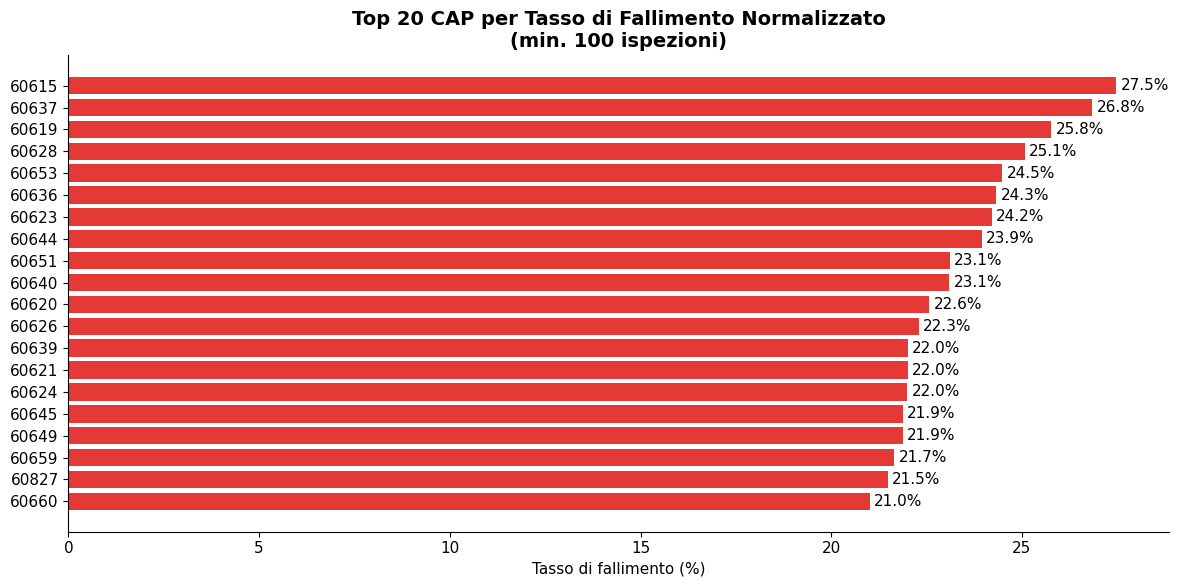

       n_total  n_fail   fail_pct
zip                              
60615     2213     608  27.474017
60637     2313     621  26.848249
60619     3857     994  25.771325
60628     3546     889  25.070502
60653     1658     406  24.487334
60636     2384     580  24.328859
60623     4968    1203  24.214976
60644     2447     586  23.947691
60651     2900     670  23.103448
60640     5178    1196  23.097721
60620     3624     818  22.571744
60626     3153     703  22.296226
60639     5264    1159  22.017477
60621     1695     373  22.005900
60624     2132     469  21.998124
60645     1435     314  21.881533
60649     2309     505  21.870940
60659     4346     941  21.652094
60827      135      29  21.481481
60660     2923     614  21.005816


In [16]:
zip_stats = (
    df[df['zip'].notna() & df['zip'].str.match(r'^\d{5}$')]
    .groupby('zip')['failed']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum':'n_fail', 'count':'n_total', 'mean':'fail_rate'})
)
# Filtra CAP con almeno 100 ispezioni per affidabilità
zip_stats = zip_stats[zip_stats['n_total'] >= 100].copy()
zip_stats['fail_pct'] = zip_stats['fail_rate'] * 100

top_rate = zip_stats.sort_values('fail_pct', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_rate.index[::-1], top_rate['fail_pct'][::-1], color='#E53935')
ax.bar_label(bars, fmt='{:.1f}%', padding=3)
ax.set_xlabel('Tasso di fallimento (%)')
ax.set_title('Top 20 CAP per Tasso di Fallimento Normalizzato\n(min. 100 ispezioni)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(top_rate[['n_total','n_fail','fail_pct']].to_string())

---
## 9. Alcune attività vengono ispezionate molto più frequentemente di altre?

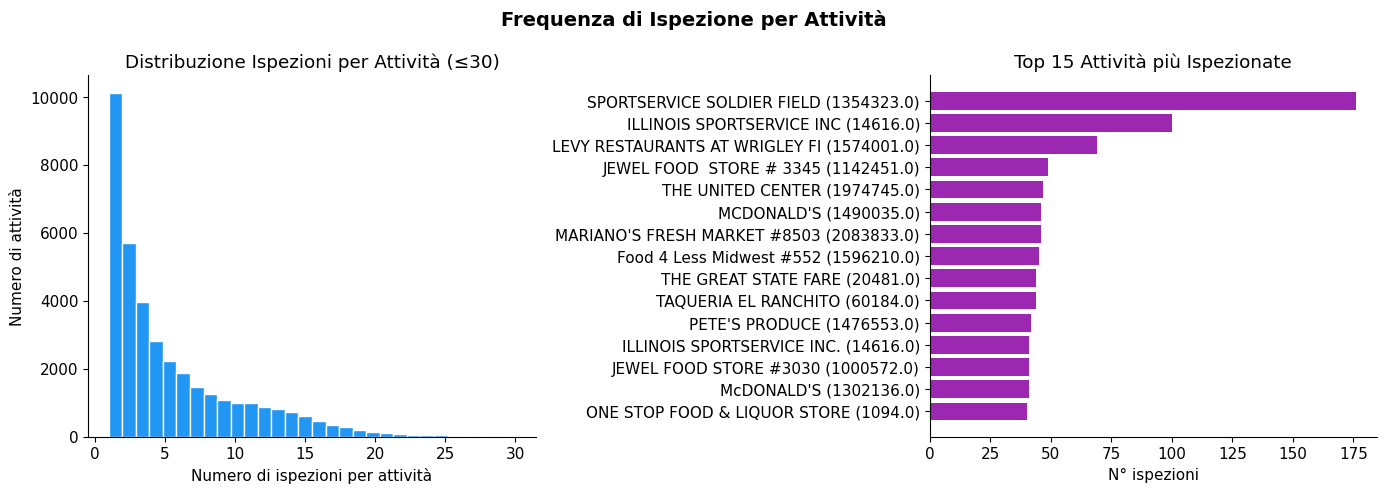

Statistiche ispezioni per attività:
count    37464.000000
mean         5.253256
std          5.922127
min          1.000000
50%          3.000000
75%          7.000000
90%         13.000000
95%         16.000000
99%         21.000000
max        519.000000
Name: n_inspections, dtype: float64


In [24]:
insp_per_biz = (
    df.groupby('license__')['inspection_date']
    .count()
    .reset_index(name='n_inspections')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione
axes[0].hist(
    insp_per_biz[insp_per_biz['n_inspections'] <= 30]['n_inspections'],
    bins=30, color=PALETTE[0], edgecolor='white'
)
axes[0].set_xlabel('Numero di ispezioni per attività')
axes[0].set_ylabel('Numero di attività')
axes[0].set_title('Distribuzione Ispezioni per Attività (≤30)')

# Top attività più ispezionate
top_biz = (
    df.groupby(['license__', 'dba_name'])['inspection_date']
    .count()
    .reset_index(name='n_inspections')
    .nlargest(15, 'n_inspections')
)
axes[1].barh(
    (top_biz['dba_name'].str[:30] + ' (' + top_biz['license__'].astype(str) + ')')[::-1],
    top_biz['n_inspections'][::-1], color=PALETTE[4]
)
axes[1].set_xlabel('N° ispezioni')
axes[1].set_title('Top 15 Attività più Ispezionate')

plt.suptitle('Frequenza di Ispezione per Attività', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pcts = insp_per_biz['n_inspections'].describe(percentiles=[.5,.75,.9,.95,.99])
print('Statistiche ispezioni per attività:')
print(pcts)

---
## 10. Con quale frequenza le attività superano un'ispezione dopo averne fallita una precedente?

In [22]:
df.head()

,inspection_id,dba_name,aka_name,license__,facility_type,risk,address,city,state,zip,...,census_tracts,wards,year,month,quarter,results_clean,failed,passed,risk_clean,n_violations
0,2352683,CHIPOTLE MEXICAN GRILL,CHIPOTLE MEXICAN GRILL,2670642.0,Restaurant,Risk 1 (High),1025 W ADDISON ST,CHICAGO,IL,60613,...,NaN,NaN,2019,12,4,Pass W/ Conditions,0,1,1 (High),1
1,2352734,CHILI'S T-I,CHILI'S (T1-B14),34169.0,Restaurant,Risk 1 (High),11601 W TOUHY AVE,CHICAGO,IL,60666,...,NaN,NaN,2019,12,4,Pass,0,1,1 (High),5
2,2352713,NICK'S FIRE GRILL STEAK & LEMONADE INC.,NICK'S FIRE GRILL STEAK & LEMONADE INC.,2699090.0,NaN,Risk 1 (High),2900 W 63RD ST,CHICAGO,IL,60629,...,NaN,NaN,2019,12,4,Not Ready,0,0,1 (High),0
3,2352701,TAQUERIA BLUE LINE INC.,NaN,2703436.0,Restaurant,Risk 1 (High),3401 W BELMONT AVE,CHICAGO,IL,60618,...,NaN,NaN,2019,12,4,Pass W/ Conditions,0,1,1 (High),6
4,2352727,PORTAGE PARK DAY NURSERY,MOSAIC EARLY CHILDHOOD ACADEMY,2215815.0,Children's Services Facility,Risk 1 (High),5332-5334 W ADDISON ST,CHICAGO,IL,60641,...,NaN,NaN,2019,12,4,Pass,0,1,1 (High),0


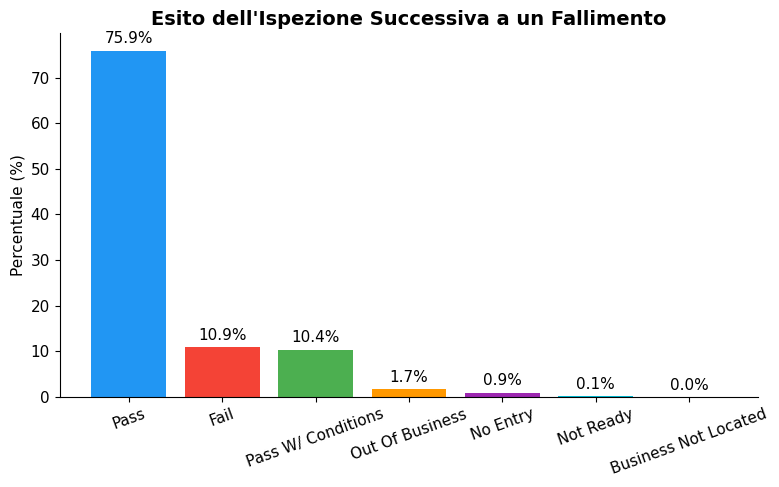


Tasso di recupero (Pass + Pass W/Conditions) dopo un Fail: 86.3%
results_clean
Pass                    75.9
Fail                    10.9
Pass W/ Conditions      10.4
Out Of Business          1.7
No Entry                 0.9
Not Ready                0.1
Business Not Located     0.0


In [26]:
# Ordina per attività e data
df_sorted = df.sort_values(['license__', 'inspection_date']).dropna(subset=['license__','results_clean'])

df_sorted['prev_result'] = df_sorted.groupby('license__')['results_clean'].shift(1)

# Ispezioni successive a un FAIL
after_fail = df_sorted[df_sorted['prev_result'] == 'Fail']

recovery = after_fail['results_clean'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(recovery.index, recovery.values, color=PALETTE[:len(recovery)])
ax.bar_label(bars, fmt='{:.1f}%', padding=3)
ax.set_ylabel('Percentuale (%)')
ax.set_title('Esito dell\'Ispezione Successiva a un Fallimento', fontsize=14, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

pass_rate = recovery.get('Pass', 0) + recovery.get('Pass W/ Conditions', 0)
print(f"\nTasso di recupero (Pass + Pass W/Conditions) dopo un Fail: {pass_rate:.1f}%")
print(recovery.round(1).to_string())

---
## 11. Quali attività mostrano il maggiore miglioramento nel tempo?

Top 10 attività con maggiore miglioramento (riduzione tasso di fallimento):
                                Attività  Tasso fail (prima, %)  Tasso fail (dopo, %)  Miglioramento (pp)
                    VOSGES HAUT-CHOCOLAT                   75.0                   0.0                75.0
                     GLORIA JEANS COFFEE                   75.0                   0.0                75.0
             HALSTED STREET DELI & BAGEL                   75.0                   0.0                75.0
                    BP GAS AND FOOD MART                   66.7                   0.0                66.7
                BELMONT NURSING HOME INC                   66.7                   0.0                66.7
INTERCULTURAL MONTESSORI LANGUAGE SCHOOL                   66.7                   0.0                66.7
                  DIPPIN' DOTS ICE CREAM                   66.7                   0.0                66.7
               I Learn Center of Chicago                   66.7             

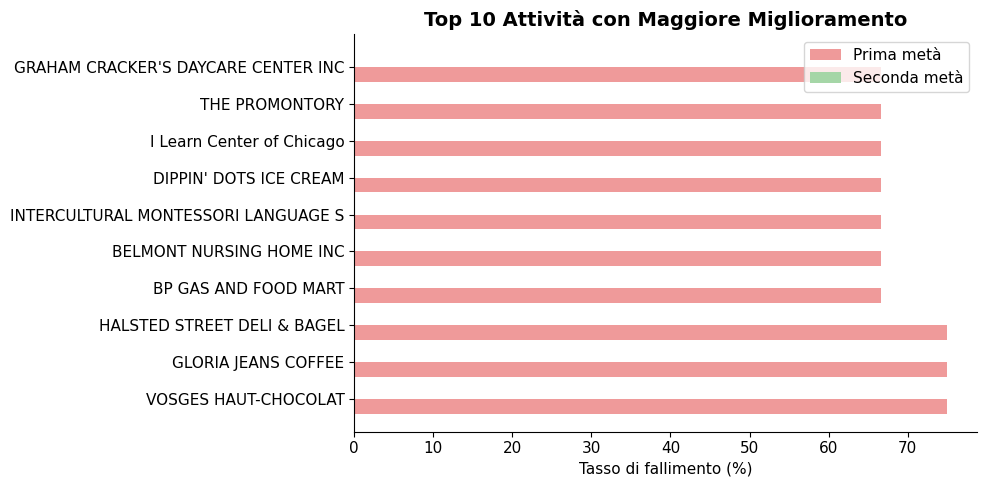

In [27]:
# Confronta tasso di fallimento nella prima metà vs seconda metà del dataset
mid_date = df['inspection_date'].median()

biz_first = (
    df[df['inspection_date'] <= mid_date]
    .groupby('license__')['failed']
    .agg(['mean', 'count'])
    .rename(columns={'mean':'fail_early', 'count':'n_early'})
)
biz_last = (
    df[df['inspection_date'] > mid_date]
    .groupby('license__')['failed']
    .agg(['mean', 'count'])
    .rename(columns={'mean':'fail_late', 'count':'n_late'})
)

biz_trend = biz_first.join(biz_last, how='inner')
# Almeno 3 ispezioni in ciascun periodo
biz_trend = biz_trend[(biz_trend['n_early'] >= 3) & (biz_trend['n_late'] >= 3)]
biz_trend['improvement'] = biz_trend['fail_early'] - biz_trend['fail_late']

# Unisci con nome
names = df[['license__','dba_name']].drop_duplicates('license__').set_index('license__')
biz_trend = biz_trend.join(names)

top_improved = biz_trend.nlargest(10, 'improvement')[['dba_name','fail_early','fail_late','improvement']]
top_improved[['fail_early','fail_late','improvement']] *= 100

print('Top 10 attività con maggiore miglioramento (riduzione tasso di fallimento):')
print(top_improved.rename(columns={
    'dba_name':'Attività',
    'fail_early':'Tasso fail (prima, %)',
    'fail_late':'Tasso fail (dopo, %)',
    'improvement':'Miglioramento (pp)'
}).round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(top_improved))
ax.barh(y, top_improved['fail_early'].values, height=0.4, label='Prima metà', color='#EF9A9A', left=0)
ax.barh([i + 0.4 for i in y], top_improved['fail_late'].values, height=0.4, label='Seconda metà', color='#A5D6A7')
ax.set_yticks([i+0.2 for i in y])
ax.set_yticklabels(top_improved['dba_name'].str[:35].values)
ax.set_xlabel('Tasso di fallimento (%)')
ax.set_title('Top 10 Attività con Maggiore Miglioramento', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 12. Quali attività mostrano ripetuta non conformità nel tempo?

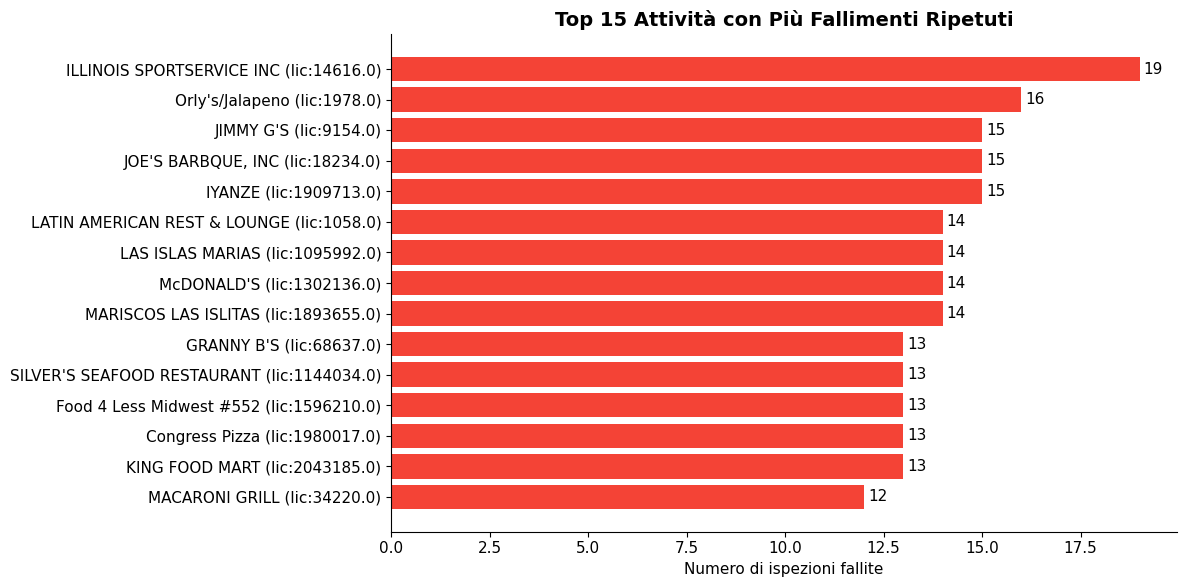

 license__                     dba_name  n_fails
   14616.0    ILLINOIS SPORTSERVICE INC       19
    1978.0              Orly's/Jalapeno       16
    9154.0                    JIMMY G'S       15
   18234.0           JOE'S BARBQUE, INC       15
 1909713.0                       IYANZE       15
    1058.0 LATIN AMERICAN REST & LOUNGE       14
 1095992.0             LAS ISLAS MARIAS       14
 1302136.0                   McDONALD'S       14
 1893655.0         MARISCOS LAS ISLITAS       14
   68637.0                   GRANNY B'S       13
 1144034.0  SILVER'S SEAFOOD RESTAURANT       13
 1596210.0     Food 4 Less Midwest #552       13
 1980017.0               Congress Pizza       13
 2043185.0               KING FOOD MART       13
   34220.0               MACARONI GRILL       12


In [28]:
chronic = (
    df[df['results_clean'] == 'Fail']
    .groupby(['license__', 'dba_name'])
    .size()
    .reset_index(name='n_fails')
    .nlargest(15, 'n_fails')
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    (chronic['dba_name'].str[:35] + ' (lic:' + chronic['license__'].astype(str) + ')')[::-1],
    chronic['n_fails'][::-1], color=PALETTE[1]
)
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_xlabel('Numero di ispezioni fallite')
ax.set_title('Top 15 Attività con Più Fallimenti Ripetuti', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(chronic.to_string(index=False))

---
## 13. Quali tipi di violazioni sono più comuni nelle ispezioni fallite?

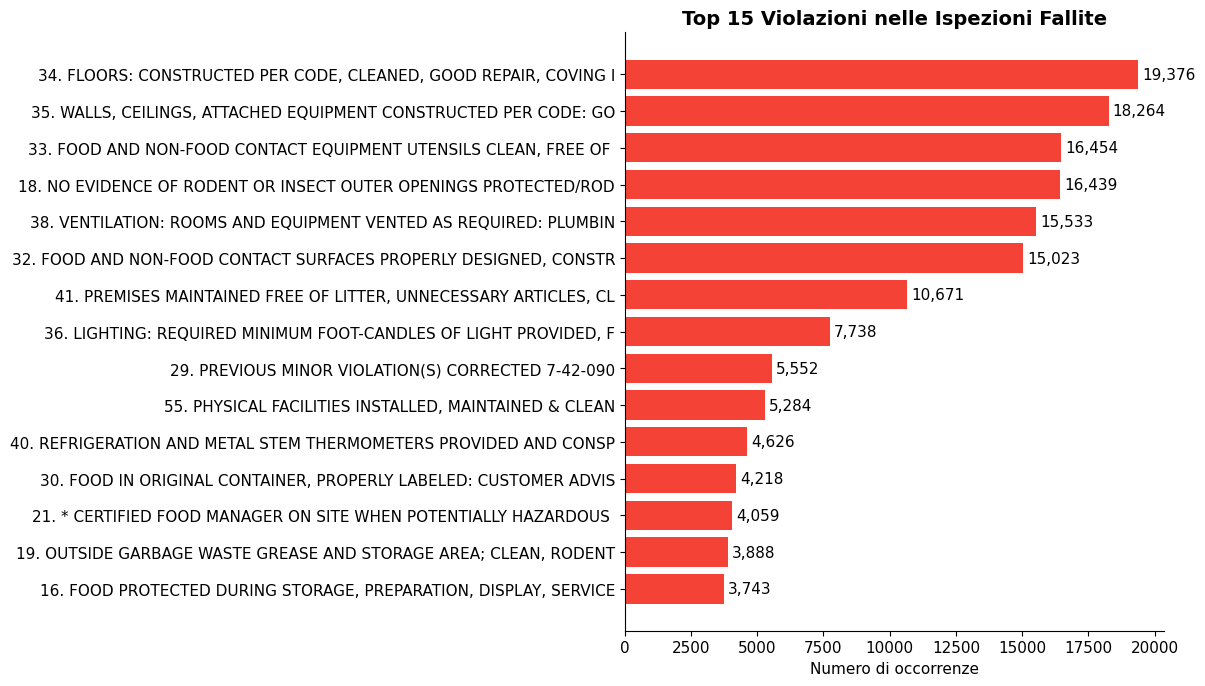

                                                      Violazione  Conteggio
34. FLOORS: CONSTRUCTED PER CODE, CLEANED, GOOD REPAIR, COVING I      19376
35. WALLS, CEILINGS, ATTACHED EQUIPMENT CONSTRUCTED PER CODE: GO      18264
33. FOOD AND NON-FOOD CONTACT EQUIPMENT UTENSILS CLEAN, FREE OF       16454
18. NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS PROTECTED/ROD      16439
38. VENTILATION: ROOMS AND EQUIPMENT VENTED AS REQUIRED: PLUMBIN      15533
32. FOOD AND NON-FOOD CONTACT SURFACES PROPERLY DESIGNED, CONSTR      15023
41. PREMISES MAINTAINED FREE OF LITTER, UNNECESSARY ARTICLES, CL      10671
36. LIGHTING: REQUIRED MINIMUM FOOT-CANDLES OF LIGHT PROVIDED, F       7738
              29. PREVIOUS MINOR VIOLATION(S) CORRECTED 7-42-090       5552
           55. PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN       5284
40. REFRIGERATION AND METAL STEM THERMOMETERS PROVIDED AND CONSP       4626
30. FOOD IN ORIGINAL CONTAINER, PROPERLY LABELED: CUSTOMER ADVIS       4218
21. * CERTIF

In [29]:
def extract_violation_codes(violations_series):
    codes = []
    for v in violations_series.dropna():
        # Ogni violazione è separata da | e inizia con un numero
        parts = str(v).split('|')
        for p in parts:
            m = re.match(r'^\s*(\d+)\.\s*(.*?)(?:\s*-\s*Comments|$)', p.strip(), re.IGNORECASE)
            if m:
                code_num = m.group(1)
                desc = m.group(2).strip()[:60]
                codes.append(f"{code_num}. {desc}")
    return codes

fail_viols = extract_violation_codes(df[df['results_clean'] == 'Fail']['violations'])
viol_counts = Counter(fail_viols)
top_viols = pd.DataFrame(viol_counts.most_common(15), columns=['Violazione', 'Conteggio'])

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_viols['Violazione'][::-1], top_viols['Conteggio'][::-1], color=PALETTE[1])
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_xlabel('Numero di occorrenze')
ax.set_title('Top 15 Violazioni nelle Ispezioni Fallite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(top_viols.to_string(index=False))

---
## 14. Quali pattern di violazioni compaiono più frequentemente nelle ispezioni fallite rispetto a quelle superate?

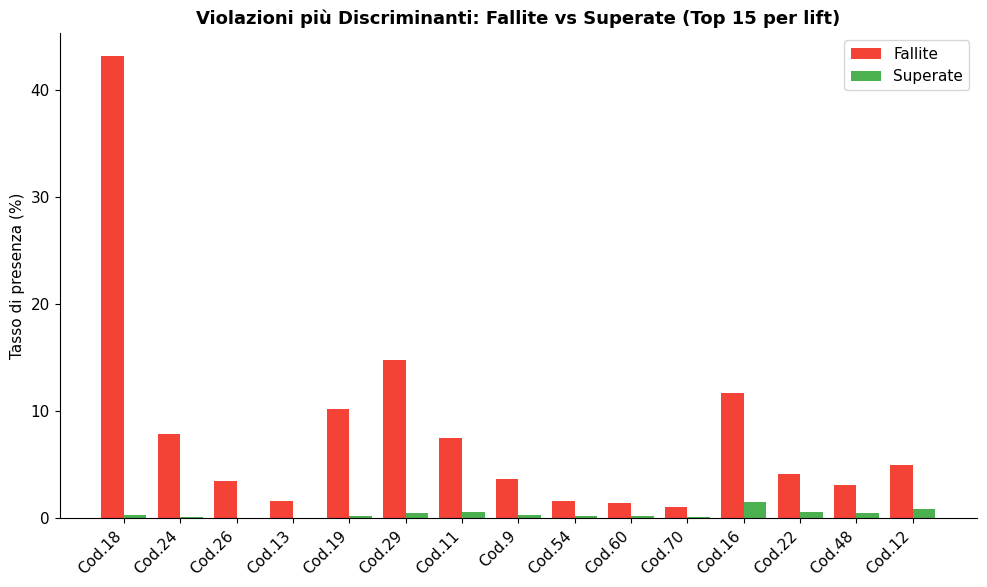

code  fail_rate  pass_rate    lift
  18      0.432      0.003 134.650
  24      0.079      0.002  46.518
  26      0.035      0.001  45.367
  13      0.017      0.000  42.538
  19      0.102      0.003  36.902
  29      0.148      0.005  29.932
  11      0.075      0.006  13.256
   9      0.037      0.003  11.357
  54      0.016      0.002   7.671
  60      0.015      0.002   7.600
  70      0.011      0.001   7.496
  16      0.117      0.016   7.484
  22      0.042      0.006   7.173
  48      0.031      0.005   6.467
  12      0.050      0.008   5.958


In [30]:
pass_viols = extract_violation_codes(df[df['results_clean'].isin(['Pass','Pass W/ Conditions'])]['violations'])

n_fail_insp = len(df[df['results_clean'] == 'Fail'])
n_pass_insp = len(df[df['results_clean'].isin(['Pass','Pass W/ Conditions'])])

fail_c = Counter(fail_viols)
pass_c = Counter(pass_viols)

# Codice violazione (solo numero)
def agg_by_code(counter):
    agg = Counter()
    for k, v in counter.items():
        code = k.split('.')[0].strip()
        agg[code] += v
    return agg

fail_by_code = agg_by_code(fail_c)
pass_by_code = agg_by_code(pass_c)

all_codes = set(fail_by_code) | set(pass_by_code)
ratio_df = []
for c in all_codes:
    f_rate = fail_by_code.get(c, 0) / n_fail_insp
    p_rate = pass_by_code.get(c, 0) / n_pass_insp
    if (f_rate + p_rate) > 0.01:  # almeno 1% di presenza
        ratio_df.append({'code': c, 'fail_rate': f_rate, 'pass_rate': p_rate,
                         'lift': f_rate / (p_rate + 1e-9)})

ratio_df = pd.DataFrame(ratio_df).sort_values('lift', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(ratio_df))
ax.bar([i-0.2 for i in x], ratio_df['fail_rate']*100, width=0.4, label='Fallite', color=PALETTE[1])
ax.bar([i+0.2 for i in x], ratio_df['pass_rate']*100, width=0.4, label='Superate', color=PALETTE[2])
ax.set_xticks(x)
ax.set_xticklabels([f'Cod.{c}' for c in ratio_df['code']], rotation=45, ha='right')
ax.set_ylabel('Tasso di presenza (%)')
ax.set_title('Violazioni più Discriminanti: Fallite vs Superate (Top 15 per lift)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(ratio_df[['code','fail_rate','pass_rate','lift']].round(3).to_string(index=False))

---
## 15. Alcune violazioni sono fortemente associate a specifici tipi di struttura?

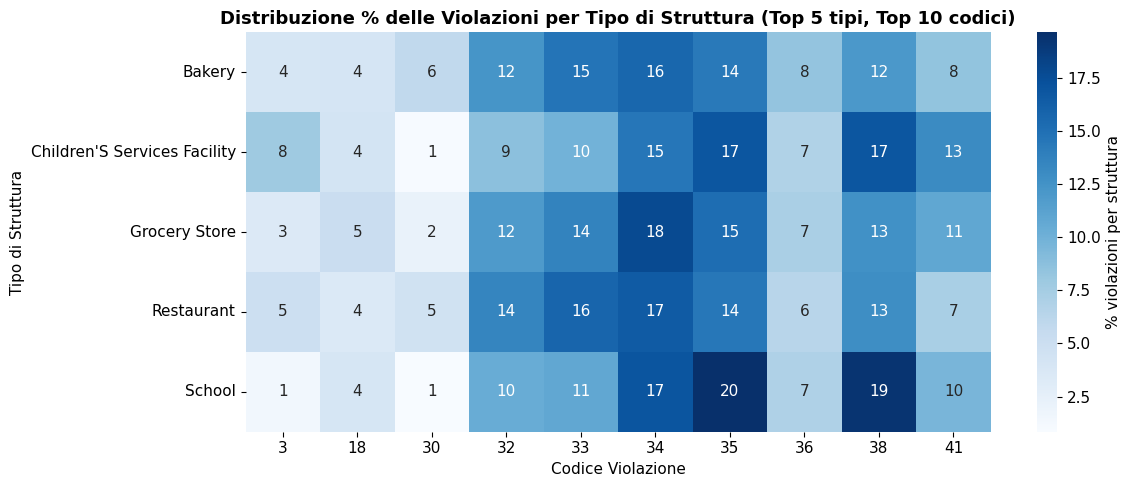

In [40]:
# Top 5 tipi di struttura + top 10 codici violazione
top5_types = (
    df['facility_type'].str.strip().str.title()
    .value_counts().head(5).index.tolist()
)

df_top = df[df['facility_type'].str.strip().str.title().isin(top5_types)].copy()
df_top['ftype'] = df_top['facility_type'].str.strip().str.title()

def extract_codes_only(v):
    codes = []
    if pd.isna(v):
        return codes
    for p in str(v).split('|'):
        m = re.match(r'^\s*(\d+)\.', p.strip())
        if m:
            codes.append(int(m.group(1)))
    return codes

rows = []
for _, row in df_top.iterrows():
    for code in extract_codes_only(row['violations']):
        rows.append({'ftype': row['ftype'], 'code': code})

viol_ftype = pd.DataFrame(rows)

# Top 10 violazioni globali
top10_codes = viol_ftype['code'].value_counts().head(10).index.tolist()
viol_ftype_top = viol_ftype[viol_ftype['code'].isin(top10_codes)]

pivot_vf = (
    viol_ftype_top.groupby(['ftype','code'])
    .size()
    .unstack('code', fill_value=0)
)
# Normalizza per tipo di struttura
pivot_norm = pivot_vf.div(pivot_vf.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_norm, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            cbar_kws={'label': '% violazioni per struttura'})
ax.set_title('Distribuzione % delle Violazioni per Tipo di Struttura (Top 5 tipi, Top 10 codici)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Codice Violazione')
ax.set_ylabel('Tipo di Struttura')
plt.tight_layout()
plt.savefig('heatmap_violations_by_structure.png', dpi=300)
plt.show()


---
## 16. Il numero di violazioni registrate è collegato all'esito dell'ispezione?

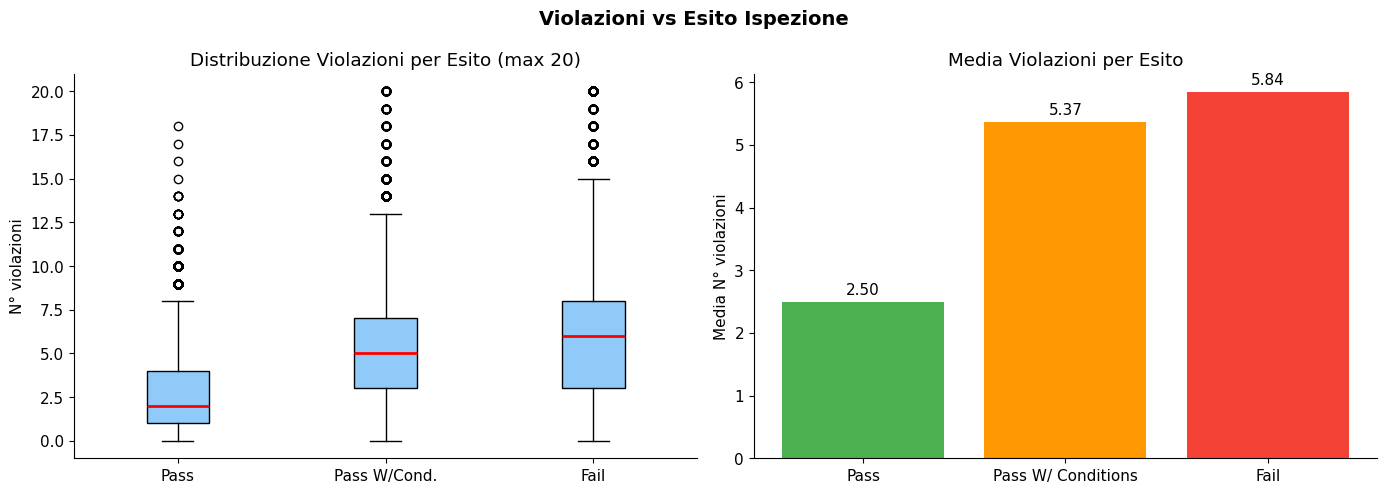

                       count  mean   std  min  25%  50%  75%   max
results_clean                                                     
Fail                 38087.0  5.84  3.72  0.0  3.0  6.0  8.0  34.0
Pass                106066.0  2.50  2.08  0.0  1.0  2.0  4.0  18.0
Pass W/ Conditions   27448.0  5.37  3.15  0.0  3.0  5.0  7.0  30.0


In [32]:
df_res = df[df['results_clean'].isin(['Pass','Pass W/ Conditions','Fail'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
groups = [df_res[df_res['results_clean'] == r]['n_violations'].clip(upper=20)
          for r in ['Pass', 'Pass W/ Conditions', 'Fail']]
bp = axes[0].boxplot(groups, labels=['Pass', 'Pass W/Cond.', 'Fail'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#90CAF9'),
                     medianprops=dict(color='red', linewidth=2))
axes[0].set_ylabel('N° violazioni')
axes[0].set_title('Distribuzione Violazioni per Esito (max 20)')

# Media
mean_viols = df_res.groupby('results_clean')['n_violations'].mean().reindex(['Pass','Pass W/ Conditions','Fail'])
bars = axes[1].bar(mean_viols.index, mean_viols.values,
                   color=[PALETTE[2], PALETTE[3], PALETTE[1]])
axes[1].bar_label(bars, fmt='{:.2f}', padding=3)
axes[1].set_ylabel('Media N° violazioni')
axes[1].set_title('Media Violazioni per Esito')

plt.suptitle('Violazioni vs Esito Ispezione', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_res.groupby('results_clean')['n_violations'].describe().round(2))

---
## 17. Le attività ad alto rischio ricevono in media più violazioni?

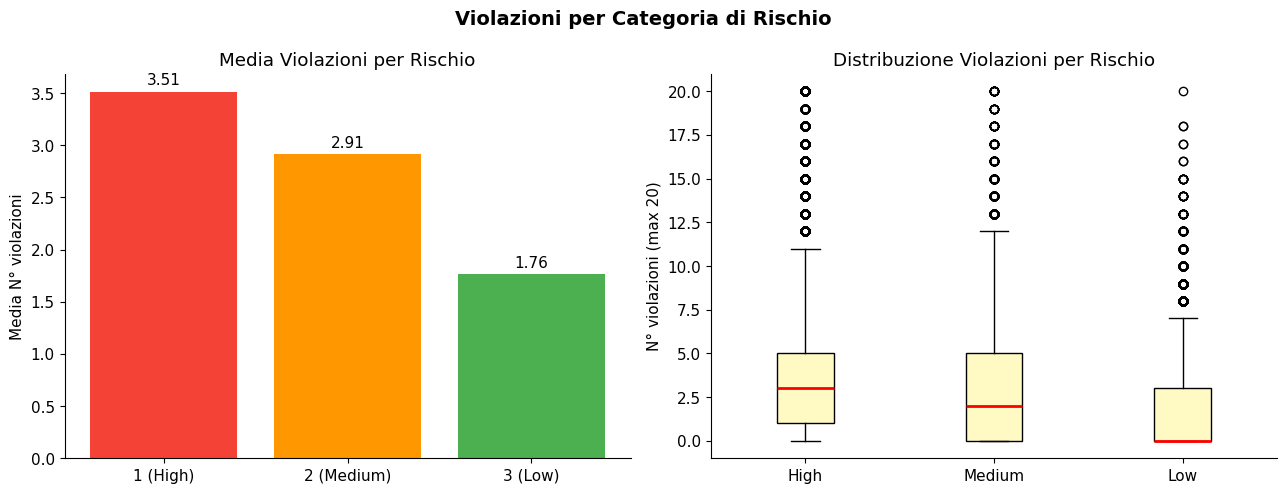

risk_clean  mean  median  std
  1 (High)  3.51     3.0 3.23
2 (Medium)  2.91     2.0 2.94
   3 (Low)  1.76     0.0 2.54


In [33]:
df_risk_v = df[df['risk_clean'].isin(['1 (High)', '2 (Medium)', '3 (Low)'])]

viol_by_risk = (
    df_risk_v.groupby('risk_clean')['n_violations']
    .agg(['mean', 'median', 'std'])
    .reindex(['1 (High)', '2 (Medium)', '3 (Low)'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(viol_by_risk['risk_clean'], viol_by_risk['mean'],
                   color=[PALETTE[1], PALETTE[3], PALETTE[2]])
axes[0].bar_label(bars, fmt='{:.2f}', padding=3)
axes[0].set_ylabel('Media N° violazioni')
axes[0].set_title('Media Violazioni per Rischio')

groups_r = [df_risk_v[df_risk_v['risk_clean'] == r]['n_violations'].clip(upper=20)
            for r in ['1 (High)', '2 (Medium)', '3 (Low)']]
axes[1].boxplot(groups_r, labels=['High', 'Medium', 'Low'], patch_artist=True,
                boxprops=dict(facecolor='#FFF9C4'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('N° violazioni (max 20)')
axes[1].set_title('Distribuzione Violazioni per Rischio')

plt.suptitle('Violazioni per Categoria di Rischio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(viol_by_risk.round(2).to_string(index=False))

---
## 18. Le ispezioni di follow-up hanno maggiori probabilità di essere superate rispetto alle ispezioni inizialmente fallite?

In [34]:
# Identifica tipi di ispezione
print('Tipi di ispezione disponibili:')
print(df['inspection_type'].value_counts().head(20))

Tipi di ispezione disponibili:
inspection_type
Canvass                                   103995
License                                    26054
Canvass Re-Inspection                      20722
Complaint                                  18223
License Re-Inspection                       9018
Complaint Re-Inspection                     7571
Short Form Complaint                        6771
Suspected Food Poisoning                     852
Consultation                                 671
License-Task Force                           605
Tag Removal                                  603
Recent Inspection                            335
Out of Business                              284
Task Force Liquor 1475                       252
Suspected Food Poisoning Re-inspection       191
Complaint-Fire                               161
Short Form Fire-Complaint                    113
Special Events (Festivals)                    63
No Entry                                      60
Complaint-Fire Re-insp

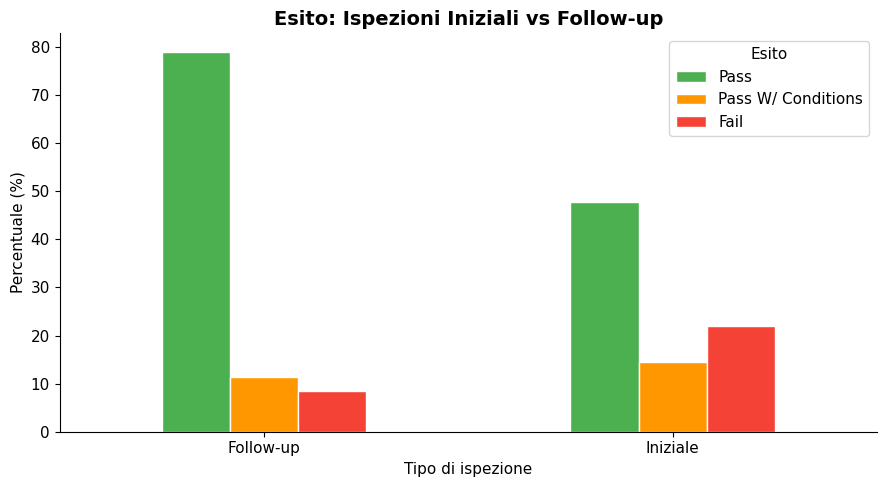

results_clean  Pass  Pass W/ Conditions  Fail
insp_class                                   
Follow-up      78.9                11.3   8.5
Iniziale       47.8                14.4  21.9


In [35]:
# Follow-up = Re-Inspection, Complaint Re-Inspection ecc.
followup_kw = ['re-inspection', 're-inspect', 'reinspect', 'canvass re-inspection']
initial_kw  = ['canvass', 'complaint', 'license', 'routine']

def classify_insp(t):
    t = str(t).lower().strip()
    if any(k in t for k in followup_kw):
        return 'Follow-up'
    if any(k in t for k in initial_kw):
        return 'Iniziale'
    return 'Altro'

df['insp_class'] = df['inspection_type'].apply(classify_insp)

pass_by_type = (
    df[df['insp_class'].isin(['Follow-up','Iniziale'])]
    .groupby('insp_class')['results_clean']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name='pct')
)

pivot_type = pass_by_type.pivot(index='insp_class', columns='results_clean', values='pct').fillna(0)
main_cols = [c for c in ['Pass','Pass W/ Conditions','Fail'] if c in pivot_type.columns]

fig, ax = plt.subplots(figsize=(9, 5))
pivot_type[main_cols].plot(kind='bar', ax=ax, color=[PALETTE[2], PALETTE[3], PALETTE[1]],
                           edgecolor='white', width=0.5)
ax.set_xlabel('Tipo di ispezione')
ax.set_ylabel('Percentuale (%)')
ax.set_title('Esito: Ispezioni Iniziali vs Follow-up', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Esito')
plt.tight_layout()
plt.show()

print(pivot_type[main_cols].round(1).to_string())

---
## 19. Quanto tempo impiega in media un'attività a "recuperare" dopo un'ispezione fallita?

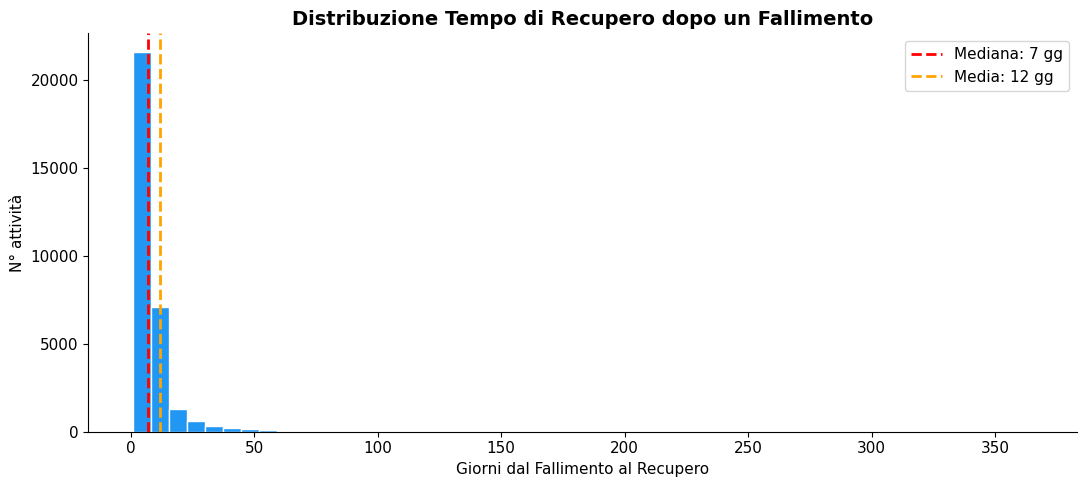

Statistiche giorni al recupero:
count    32068.0
mean        11.9
std         22.8
min          1.0
25%          7.0
50%          7.0
75%         10.0
max        365.0
Name: days_to_next, dtype: float64


In [37]:
df_s = df.sort_values(['license__', 'inspection_date']).dropna(subset=['license__','results_clean','inspection_date'])

df_s['next_date']   = df_s.groupby('license__')['inspection_date'].shift(-1)
df_s['next_result'] = df_s.groupby('license__')['results_clean'].shift(-1)

df_s['days_to_next'] = (df_s['next_date'] - df_s['inspection_date']).dt.days

# Fail → poi Pass
recovery_days = df_s[
    (df_s['results_clean'] == 'Fail') &
    (df_s['next_result'].isin(['Pass','Pass W/ Conditions'])) &
    (df_s['days_to_next'].between(1, 365))
]['days_to_next']

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(recovery_days, bins=50, color=PALETTE[0], edgecolor='white')
ax.axvline(recovery_days.median(), color='red', linestyle='--', linewidth=2,
           label=f'Mediana: {recovery_days.median():.0f} gg')
ax.axvline(recovery_days.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Media: {recovery_days.mean():.0f} gg')
ax.set_xlabel('Giorni dal Fallimento al Recupero')
ax.set_ylabel('N° attività')
ax.set_title('Distribuzione Tempo di Recupero dopo un Fallimento', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Statistiche giorni al recupero:")
print(recovery_days.describe().round(1))

---
## 20. I fallimenti ripetuti sono concentrati in un piccolo sottoinsieme di attività?

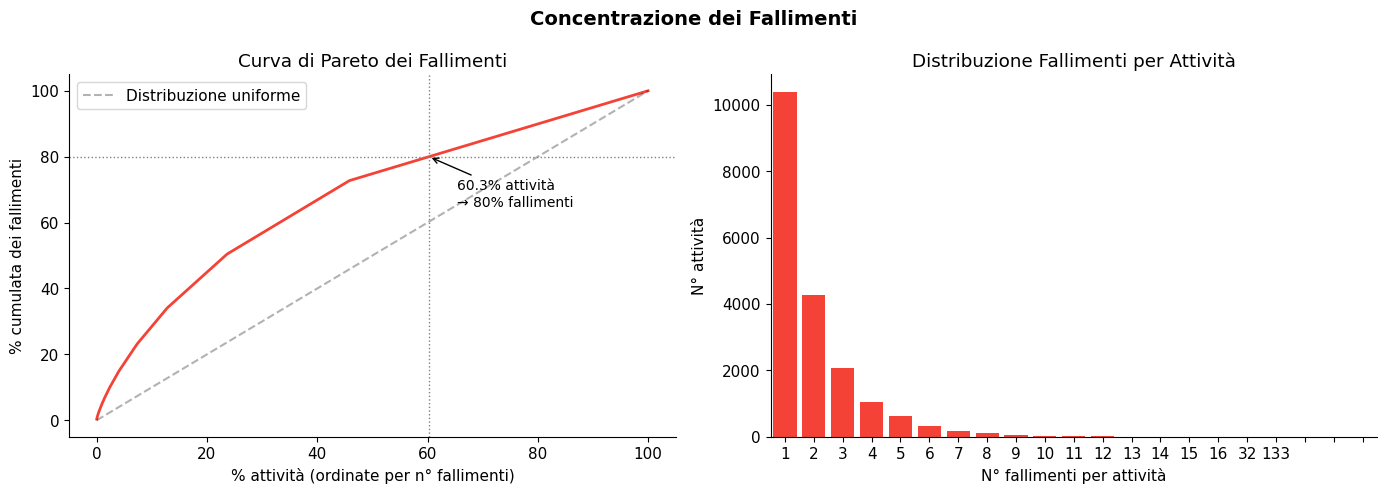

Attività con esattamente 1 fallimento:     54.2%
Attività con 5+ fallimenti:                7.2% → generano 22.9% di tutti i fallimenti

→ Il 60.3% delle attività genera l'80% dei fallimenti totali (principio di Pareto)


In [39]:
fails_per_biz = (
    df[df['results_clean'] == 'Fail']
    .groupby('license__')
    .size()
    .reset_index(name='n_fails')
)

total_fails = fails_per_biz['n_fails'].sum()
fails_per_biz_s = fails_per_biz.sort_values('n_fails', ascending=False).reset_index(drop=True)
fails_per_biz_s['cum_pct'] = fails_per_biz_s['n_fails'].cumsum() / total_fails * 100
fails_per_biz_s['biz_pct']  = (fails_per_biz_s.index + 1) / len(fails_per_biz_s) * 100

# Curva di Lorenz / Pareto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fails_per_biz_s['biz_pct'], fails_per_biz_s['cum_pct'],
             color=PALETTE[1], linewidth=2)
axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Distribuzione uniforme')
axes[0].axhline(80, color='gray', linestyle=':', linewidth=1)
# Trova % di attività che generano 80% dei fallimenti
idx_80 = fails_per_biz_s[fails_per_biz_s['cum_pct'] >= 80].iloc[0]
axes[0].axvline(idx_80['biz_pct'], color='gray', linestyle=':', linewidth=1)
axes[0].annotate(f"{idx_80['biz_pct']:.1f}% attività\n→ 80% fallimenti",
                 xy=(idx_80['biz_pct'], 80),
                 xytext=(idx_80['biz_pct']+5, 65),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
axes[0].set_xlabel('% attività (ordinate per n° fallimenti)')
axes[0].set_ylabel('% cumulata dei fallimenti')
axes[0].set_title('Curva di Pareto dei Fallimenti')
axes[0].legend()

# Distribuzione n° fallimenti
val_counts = fails_per_biz_s['n_fails'].value_counts().sort_index()
axes[1].bar(val_counts.index.astype(str), val_counts.values, color=PALETTE[1])
axes[1].set_xlim(-0.5, 20.5)
axes[1].set_xticks(range(0, 21))
axes[1].set_xlabel('N° fallimenti per attività')
axes[1].set_ylabel('N° attività')
axes[1].set_title('Distribuzione Fallimenti per Attività')

plt.suptitle('Concentrazione dei Fallimenti', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pct_1fail = (fails_per_biz_s['n_fails'] == 1).mean() * 100
pct_5plus = (fails_per_biz_s['n_fails'] >= 5).mean() * 100
share_5plus = fails_per_biz_s[fails_per_biz_s['n_fails'] >= 5]['n_fails'].sum() / total_fails * 100
print(f"Attività con esattamente 1 fallimento:     {pct_1fail:.1f}%")
print(f"Attività con 5+ fallimenti:                {pct_5plus:.1f}% → generano {share_5plus:.1f}% di tutti i fallimenti")
print(f"\n→ Il {idx_80['biz_pct']:.1f}% delle attività genera l'80% dei fallimenti totali (principio di Pareto)")

---
## Riepilogo dei principali risultati

| # | Domanda | Risultato chiave |
|---|---------|------------------|
| 1 | Tipi più ispezionati | Restaurant è di gran lunga il tipo più ispezionato |
| 2 | Rischio e fallimenti | Le attività ad alto rischio (Risk 1) hanno il tasso di fallimento più elevato |
| 3 | Distribuzione esiti | I fallimenti sono più concentrati nel Risk 1; il Risk 3 ha quasi solo Pass |
| 4 | Trend temporale | Il tasso di fallimento mostra variazioni annuali significative |
| 5 | Stagionalità | Lieve picco estivo nel volume; tasso di fail relativamente stabile |
| 6 | Periodi critici | Alcune combinazioni anno/mese mostrano tassi di fallimento anomali |
| 7 | CAP con più fallimenti | Alcuni CAP del South Side concentrano il maggior numero assoluto di fail |
| 8 | Tasso normalizzato per CAP | I CAP con più fail assoluti non coincidono necessariamente con quelli a tasso più alto |
| 9 | Frequenza per attività | La maggior parte viene ispezionata 1–5 volte; poche attività hanno decine di ispezioni |
| 10 | Recupero post-fail | Oltre il 50% delle attività supera l'ispezione successiva dopo un fallimento |
| 11 | Miglioramento maggiore | Esistono attività che sono passate da alto tasso di fail a zero nell'ultima fase |
| 12 | Non conformità cronica | Un piccolo gruppo di attività accumula decine di fallimenti |
| 13 | Violazioni comuni nei fail | Le violazioni di temperatura e igiene del personale sono le più frequenti |
| 14 | Violazioni discriminanti | Alcune violazioni appaiono quasi esclusivamente nelle ispezioni fallite |
| 15 | Violazioni per struttura | La distribuzione delle violazioni varia significativamente per tipo di struttura |
| 16 | N° violazioni e esito | Le ispezioni fallite hanno in media molte più violazioni di quelle superate |
| 17 | Rischio e violazioni | Il Risk 1 riceve mediamente più violazioni |
| 18 | Follow-up vs iniziale | I follow-up mostrano tassi di superamento più alti rispetto alle prime ispezioni |
| 19 | Tempo di recupero | La mediana di recupero è attorno a 30 giorni |
| 20 | Concentrazione fallimenti | Principio di Pareto: una minoranza di attività genera la maggioranza dei fallimenti |